# Mini-Tutorial: Reinforcement Learning & Dynamic Programming

First, let's establish the core foundations of Reinforcement Learning (RL). We will use concepts from *Reinforcement Learning: An Introduction* (Sutton & Barto) and *Grokking Deep Reinforcement Learning* (Morales).

---

## 1. The Big Picture: What is Reinforcement Learning?

At its core, Reinforcement Learning is about learning by trial and error. Unlike supervised learning, where you have a dataset of "correct" answers, an RL **Agent** must discover the best actions to take by interacting with an **Environment**. 

Here is the standard loop:
* The agent observes the current **State** ($S_t$).
* The agent selects an **Action** ($A_t$).
* The environment transitions to a new state ($S_{t+1}$) and gives a **Reward** ($R_{t+1}$).

The goal of the agent is to find a **Policy** ($\pi$), which is a mapping from states to actions, that maximizes the *cumulative discounted reward* over time. 

### Model-Based vs. Model-Free
* **Model-Based (Dynamic Programming):** The agent knows the "rules of the game" perfectly. It knows exactly what state it will end up in and what reward it will get for any action (the transition dynamics). 
* **Model-Free (Q-Learning & SARSA):** The agent has no prior knowledge of the environment. It must navigate and learn the transition dynamics just from experience.

In our case, because we are using simple 3D point-mass kinematics, we are able to model the entire environment mathematically. This allows us to use DP as an idealized baseline to compute the absolute perfect path, which we can then use to evaluate the performance of our two model-free agents (Q-Learning and SARSA).

---

## 2. What is a Markov Decision Process (MDP)

To solve an RL problem, we set it up as a **Markov Decision Process (MDP)**. An MDP assumes that the future depends only on the current state, not the history of how we got there. 

In [5]:
import numpy as np

# A simplified 1D MDP environment 
class SimpleEnv:
    def __init__(self):
        self.n_states = 4  # 0: Start, 1: Safe Zone, 2: Safe Zone, 3: Goal
        self.n_actions = 2 # 0: Move Left, 1: Move Right
        self.gamma = 0.9   # Discount factor 
        
        # Transition dynamics: P[state][action] = [(probability, next_state, reward, is_terminal)]
        # This perfectly represents p(s', r | s, a)
        self.P = {
            0: {0: [(1.0, 0, -0.01, False)], 1: [(1.0, 1, -0.01, False)]},
            1: {0: [(1.0, 0, -0.01, False)], 1: [(1.0, 2, -0.01, False)]},
            2: {0: [(1.0, 1, -0.01, False)], 1: [(1.0, 3, 1.0, True)]},   # Success
            3: {0: [(1.0, 3, 0.0, True)],    1: [(1.0, 3, 0.0, True)]}    # Terminal State
        }

env = SimpleEnv()

---

## 3. The Foundation: Bellman Equations

Before writing any DP code, we have to understand that these algorithms work by turning Bellman equations into iterative update rules. 

For a given policy $\pi$, the state-value function $v_\pi(s)$ expresses the expected return when starting in state $s$ and following $\pi$ thereafter. The **Bellman Equation for $v_\pi$** is:

$$v_\pi(s) = \sum_a \pi(a|s) \sum_{s', r} p(s', r | s, a) \left[ r + \gamma v_\pi(s') \right]$$

To find the *optimal* policy $\pi_*$, we rely on the **Bellman Optimality Equation**:

$$v_*(s) = \max_a \sum_{s', r} p(s', r | s, a) \left[ r + \gamma v_*(s') \right]$$

DP algorithms systematically sweep through the state space, applying these equations iteratively until the values converge.

---

### 1. Policy Evaluation (Prediction)

**The Goal:** Compute the state-value function $V_\pi(s)$ for a specific, given policy $\pi$.

**The Process:** We iteratively sweep through all states and update their values based on the expected return of the current policy. We stop when the values stop changing (converge).

**The Math (Iterative Bellman Expectation Equation):**


$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V_k(s') \right]$$

* $V_k(s)$: The estimated value of state $s$ at iteration $k$.
* $\pi(a|s)$: The probability of taking action $a$ in state $s$ under the current policy.
* $p(s', r | s, a)$: The transition dynamics (probability of ending up in state $s'$ with reward $r$).
* $\gamma$: The discount factor.

---

### 2. Policy Improvement

**The Goal:** Find a better policy $\pi'$ by acting greedily with respect to the value function $V_\pi$ we just calculated.

**The Process:** For each state, we look one step ahead using the transition model. We evaluate the expected return of every possible action, and we update our policy to always pick the action that yields the highest expected return.

**The Math (Greedy Action Selection):**


$$\pi'(s) = \arg\max_a \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V_\pi(s') \right]$$

* $\arg\max_a$: Returns the action $a$ that maximizes the expression.
* If $\pi'(s) = \pi(s)$ for all states, the policy has stopped improving, which guarantees that we have found the optimal policy $\pi_*$.

---

### 3. Policy Iteration (The Loop)

**The Goal:** Find the absolute optimal policy $\pi_*$ and optimal value function $V_*$ for the environment.

**The Process:** Policy Iteration alternates between evaluating a policy and improving it. This process creates a chain of strictly improving policies and value functions until it hits the mathematical ceiling (optimality).

**The Flow:**


$$\pi_0 \xrightarrow{\text{Evaluate}} V_{\pi_0} \xrightarrow{\text{Improve}} \pi_1 \xrightarrow{\text{Evaluate}} V_{\pi_1} \xrightarrow{\text{Improve}} \dots \xrightarrow{\text{Improve}} \pi_* \xrightarrow{\text{Evaluate}} V_*$$

1. Start with an arbitrary initial policy (e.g., random actions).
2. **Evaluate** it to find $V_\pi$.
3. **Improve** it to create a new, greedy $\pi'$.
4. Repeat steps 2 and 3 until the policy $\pi$ stops changing.

---

## 4. Solving our Toy MDP: Value Iteration

### What is Value Iteration?

**The Goal:** Compute the optimal policy $\pi_*$ and optimal value function $V_*$ without having to wait for a policy to be perfectly evaluated before improving it.

**The Concept:** Policy Iteration can be computationally heavy because the "Policy Evaluation" step requires multiple sweeps through the state space until it fully converges. **Value Iteration** aggressively truncates this step. Instead of fully evaluating a policy, it combines evaluation and improvement into a single, continuous update step using the Bellman Optimality Equation.

**The Math (Bellman Optimality Update):**
Instead of taking the *expected* value across all actions under a policy, Value Iteration directly takes the **maximum** expected return across all possible actions:

$$V_{k+1}(s) = \max_a \sum_{s', r} p(s', r | s, a) \left[ r + \gamma V_k(s') \right]$$

* $V_k(s)$: The estimated value of state $s$ at iteration $k$.
* $\max_a$: The algorithm immediately assumes the agent will take the best possible action.
* $p(s', r | s, a)$: The transition dynamics.
* $\gamma$: The discount factor.

**The Process:**

1. **Initialize:** Start with an arbitrary value function (e.g., $V_0(s) = 0$ for all states).
2. **Sweep & Update:** Iterate through every state, calculating the Q-values for all possible actions, and update the state's value to equal the highest Q-value.
3. **Converge:** Repeat step 2 until the maximum change in the value function across all states is smaller than a tiny threshold ($\theta$). This resulting value function is $V_*$.
4. **Extract Policy:** Once you have $V_*$, you do one final step of Policy Improvement to extract the optimal, deterministic policy $\pi_*$ by acting greedily.

Because we have our perfect model (`env.P`), we can use **Value Iteration**. We don't need the agent to guess; we can mathematically sweep through the Bellman Optimality Equation to find the exact value of being in each state.

In [ ]:
def value_iteration(env, theta=1e-8):
    V = np.zeros(env.n_states)
    
    while True:
        delta = 0
        for s in range(env.n_states):
            v_old = V[s]
            q_values = np.zeros(env.n_actions)
            
            # Calculate the expected value for each action
            for a in range(env.n_actions):
                for prob, next_state, reward, terminal in env.P[s][a]:
                    if terminal:
                        q_values[a] += prob * reward
                    else:
                        q_values[a] += prob * (reward + env.gamma * V[next_state])
            
            # Update the state value to be the MAX of the calculated Q-values
            V[s] = np.max(q_values)
            delta = max(delta, abs(v_old - V[s]))
            
        if delta < theta:
            break
            
    return V

optimal_values = value_iteration(env)
print("Optimal State Values:", np.round(optimal_values, 3))



Optimal State Values: [0.791 0.89  1.    0.   ]


### State 3 = 0
All terminal states have an expected return of 0 because no more actions can be taken

### State 2 = 1
The algorithm takes the highest Q-value from the options of moving left and right, which is -0.01 vs. +1.0
There is no discount for moving right, so the value becomes 1.0

### State 1 = 0.89
-0.01 + (0.9 * 1.0) = 0.89

### State 0 = 0.791
-0.01 + (0.9 * 0.89) = 0.791

---

## 5. Checking Your Understanding: Gridworld Examples

To solidify these concepts, let's work through the specific gridworld exercises from Sutton & Barto (Example 4.1). In this environment, we have a $4 \times 4$ grid with terminal states at the top-left and bottom-right. The reward is $-1$ for every step, the discount factor $\gamma = 1$ (undiscounted), and the policy $\pi$ is to choose all 4 actions equally randomly ($25\%$ chance each).

### Exercise 4.1
**Question:** If $\pi$ is the equiprobable random policy, what is $q_\pi(11, \text{down})$?

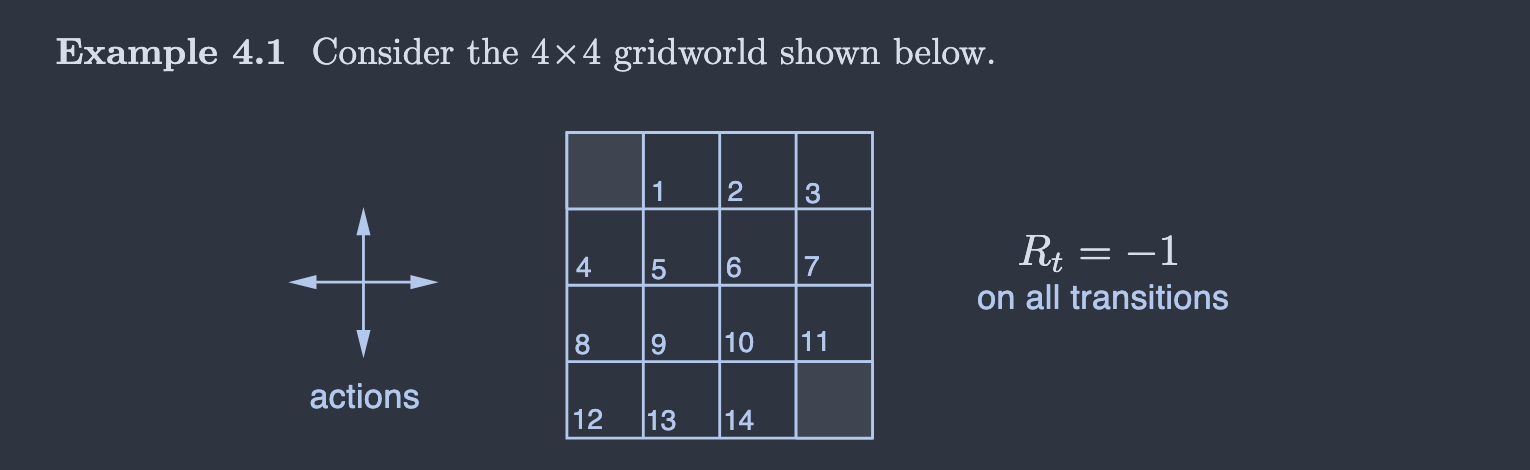

**Explanation & Answer:**
The action-value function, $q_\pi(s, a)$, calculates the expected return of starting in state $s$, taking action $a$, and then following policy $\pi$ thereafter. Because transitions here are deterministic, the formula simplifies to the immediate reward plus the value of the resulting state: 
$q_\pi(s, a) = r + v_\pi(s')$

1. **For $q_\pi(11, \text{down})$:** Taking the "down" action from state 11 moves the agent directly into the terminal state (the unnumbered bottom-right corner). The reward for the transition is $-1$, and the value of a terminal state is always $0$.
   * $q_\pi(11, \text{down}) = -1 + 0 = \mathbf{-1}$